In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned_churn.csv")

In [2]:
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

In [3]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["services_count"] = (
    df[service_columns]
    .apply(lambda column: column.isin(["Yes", "Yes"]).astype(int))
    .sum(axis=1)
)

In [4]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6 months", "7-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

In [5]:
df["has_security_or_support"] = (
    (df["OnlineSecurity"] == "Yes") |
    (df["TechSupport"] == "Yes")
).astype(int)

In [6]:
df[
    [
        "Churn",
        "ChurnFlag",
        "services_count",
        "tenure_group",
        "has_security_or_support"
    ]
].head()

,Churn,ChurnFlag,services_count,tenure_group,has_security_or_support
0,No,0,1,0-6 months,0
1,No,0,3,25-48 months,1
2,Yes,1,3,0-6 months,1
3,No,0,3,25-48 months,1
4,Yes,1,1,0-6 months,0


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [8]:
X = df.drop(columns=["customerID", "Churn", "ChurnFlag"])
y = df["ChurnFlag"]

In [9]:
categorical_columns = X.select_dtypes(include=["object", "category"]).columns
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", list(categorical_columns))
print("Numeric columns:", list(numeric_columns))

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'services_count', 'has_security_or_support']


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ]
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5625, 22)
(1407, 22)


In [13]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [15]:
y_pred = logistic_model.predict(X_test)
y_probability = logistic_model.predict_proba(X_test)[:, 1]

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probability))

Accuracy: 0.7896233120113717
Precision: 0.6258064516129033
Recall: 0.5187165775401069
F1 Score: 0.5672514619883041
ROC-AUC: 0.8372361793436903


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



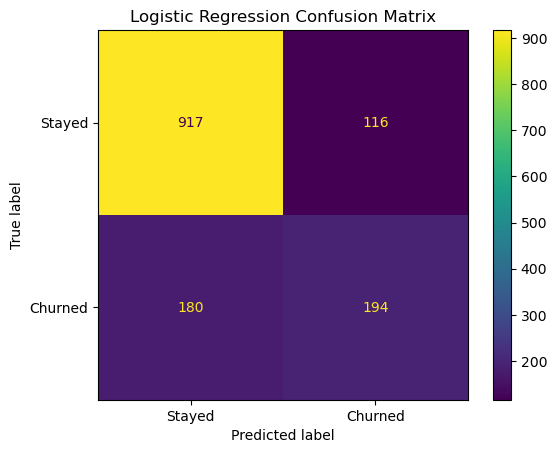

In [19]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
rf_pred = random_forest_model.predict(X_test)
rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_probability))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407

Random Forest ROC-AUC: 0.8156555590642488


In [23]:
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_probability))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_probability))

Logistic Regression ROC-AUC: 0.8372361793436903
Random Forest ROC-AUC: 0.8156555590642488


In [24]:
from sklearn.metrics import roc_curve

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_probability),
        roc_auc_score(y_test, rf_probability)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.789623,0.625806,0.518717,0.567251,0.837236
1,Random Forest,0.784648,0.621160,0.486631,0.545727,0.815656


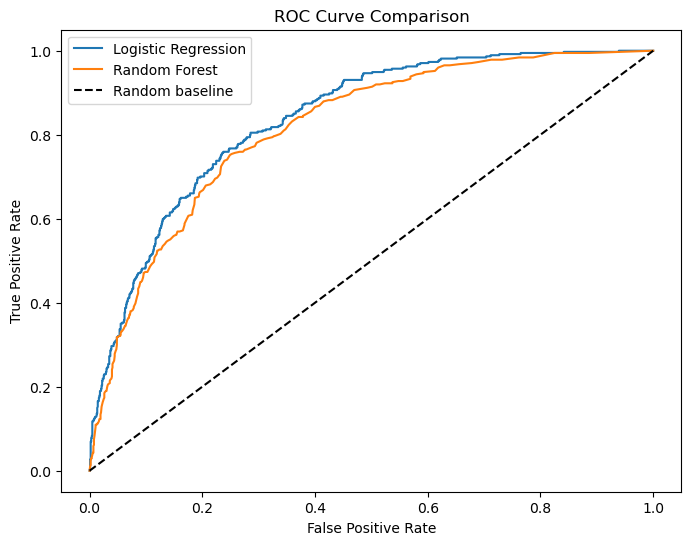

In [25]:
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, y_probability)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probability)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [26]:
selected_model = random_forest_model

In [27]:
df["churn_probability"] = selected_model.predict_proba(X)[:, 1]

In [28]:
df["risk_category"] = pd.cut(
    df["churn_probability"],
    bins=[0, 0.30, 0.70, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

In [29]:
high_risk_customers = (
    df[
        [
            "customerID",
            "tenure",
            "Contract",
            "MonthlyCharges",
            "churn_probability",
            "risk_category"
        ]
    ]
    .sort_values("churn_probability", ascending=False)
)

high_risk_customers.head(20)

,customerID,tenure,Contract,MonthlyCharges,churn_probability,risk_category
6614,9248-OJYKK,1,Month-to-month,76.45,1.0,High Risk
6482,9728-FTTVZ,1,Month-to-month,69.20,1.0,High Risk
2922,5542-TBBWB,1,Month-to-month,69.90,1.0,High Risk
2886,0495-RVCBF,1,Month-to-month,79.70,1.0,High Risk
4074,7665-TOALD,1,Month-to-month,69.60,1.0,High Risk
4455,4603-JANFB,1,Month-to-month,69.85,1.0,High Risk
3420,4510-HIMLV,1,Month-to-month,69.80,1.0,High Risk
3765,5960-WPXQM,1,Month-to-month,79.05,1.0,High Risk
6753,7660-HDPJV,1,Month-to-month,69.20,1.0,High Risk
3743,4424-TKOPW,2,Month-to-month,93.85,1.0,High Risk


In [30]:
df["risk_category"].value_counts()

risk_category
Low Risk       4939
High Risk      1406
Medium Risk     687
Name: count, dtype: int64

In [31]:
df.to_csv("../data/churn_scored.csv", index=False)

In [32]:
df[
    [
        "customerID",
        "churn_probability",
        "risk_category"
    ]
].head()

,customerID,churn_probability,risk_category
0,7590-VHVEG,0.235,Low Risk
1,5575-GNVDE,0.010,Low Risk
2,3668-QPYBK,0.795,High Risk
3,7795-CFOCW,0.005,Low Risk
4,9237-HQITU,0.810,High Risk


In [33]:
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_values = (
    random_forest_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance_values
    })
    .sort_values("importance", ascending=False)
)

feature_importance.head(15)

,feature,importance
3,numeric__TotalCharges,0.121685
2,numeric__MonthlyCharges,0.113684
1,numeric__tenure,0.111851
38,categorical__Contract_Month-to-month,0.066885
20,categorical__OnlineSecurity_No,0.033384
40,categorical__Contract_Two year,0.032516
45,categorical__PaymentMethod_Electronic check,0.029888
4,numeric__services_count,0.028695
29,categorical__TechSupport_No,0.028306
18,categorical__InternetService_Fiber optic,0.024619


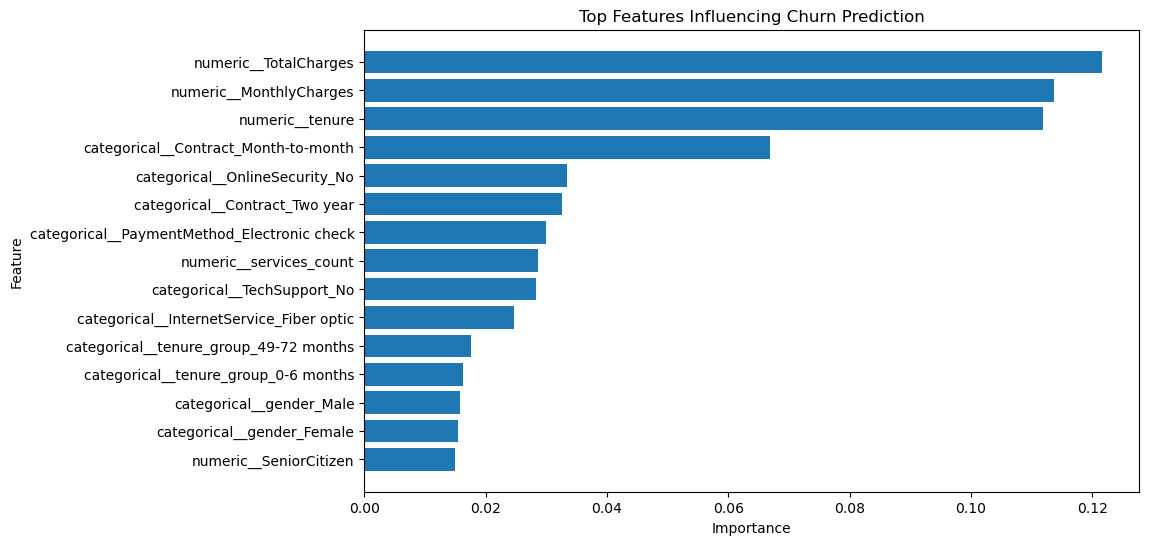

In [34]:
top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top Features Influencing Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [35]:
from pathlib import Path
import joblib

Path("../models").mkdir(exist_ok=True)

joblib.dump(
    selected_model,
    "../models/churn_model.joblib"
)

['../models/churn_model.joblib']

In [36]:
loaded_model = joblib.load(
    "../models/churn_model.joblib"
)

loaded_model.predict_proba(X.head(3))[:, 1]

array([0.235, 0.01 , 0.795])